# Module A: Lightweight DBMS with B+ Tree Index
## CS 432 Databases - Assignment 2

## 1. Introduction

### Problem Statement
Efficient data storage and retrieval are fundamental challenges in computer science, particularly in database systems and file indexing. Linear search (brute force) becomes prohibitively slow as data grows, with O(n) time complexity for insertions, deletions, and searches.

### Proposed Solution
A **B+ Tree** is a self-balancing tree structure that provides:
- **O(log n)** operations for insert, delete, and search
- Optimized **range queries** via linked leaf nodes
- **Automatic balancing** to maintain performance guarantees
- **Key-value storage** for associating records with indexed values

This project implements a complete B+ Tree DBMS from scratch and benchmarks it against a brute-force baseline, demonstrating the performance advantages of structured indexing.

## 2. Implementation Details

### B+ Tree Architecture

The B+ Tree implementation consists of:

1. **BPlusTreeNode (Dataclass)**
   - `is_leaf`: Boolean flag to distinguish leaf from internal nodes
   - `keys`: Sorted list of integer keys
   - `values`: Associated objects stored with keys (in leaf nodes)
   - `children`: Child node references (only in internal nodes)
   - `next`: Pointer to next leaf node (creates linked list for range scans)

2. **Key Operations**
   - **Insert (O(log n))**: Inserts key-value pairs while maintaining B+ tree invariants. Automatically splits full nodes.
   - **Delete (O(log n))**: Removes keys with proper merging and borrowing to maintain minimum key counts.
   - **Search (O(log n))**: Traverses tree to find exact key match.
   - **Range Query (O(log n + output))**: Uses linked leaf nodes for efficient range scans.
   - **Update (O(log n))**: Modifies value associated with existing key.

3. **Node Balancing**
   - **Split**: When a node excels `max_keys`, it splits into two nodes at the median.
   - **Borrow**: When a node underflows, it borrows keys from siblings if possible.
   - **Merge**: If borrowing is impossible, nodes merge with siblings.

### Key Design Features
- **Order Parameter**: Determines branching factor (default=4). Higher order = fewer levels, broader nodes.
- **Leaf Linkage**: Leaf nodes form a doubly-linked list, enabling efficient sequential scans (critical for range queries).
- **In-memory Storage**: Values are stored in leaf nodes only, reducing memory overhead for internal nodes.
- **Graphviz Visualization**: Tree structure rendered as directed graph with dashed lines showing leaf linkages.

### Bruteforce Baseline
- Simple list-based storage with linear scans
- O(n) for insert, search, delete; O(n) for range query
- Serves as performance comparison baseline

In [10]:
import sys
sys.path.insert(0, './Module_A')

import matplotlib.pyplot as plt
import pandas as pd
from database.db_manager import PerformanceAnalyzer, DatabaseManager
from database.table import Table
from database.bplustree import BPlusTree

print(" Imports successful. Running performance benchmarks ")

# Run performance analysis
analyzer = PerformanceAnalyzer()
sizes = [100, 500, 1000, 2000, 5000, 10000]
results = analyzer.benchmark(sizes, seed=42)

# Convert to DataFrame for easy display
df_results = pd.DataFrame([
    {
        'Size': r.size,
        'Insert B+Tree (ms)': r.insert_bptree_s * 1000,
        'Insert Brute (ms)': r.insert_bruteforce_s * 1000,
        'Search B+Tree (ms)': r.search_bptree_s * 1000,
        'Search Brute (ms)': r.search_bruteforce_s * 1000,
        'Delete B+Tree (ms)': r.delete_bptree_s * 1000,
        'Delete Brute (ms)': r.delete_bruteforce_s * 1000,
        'Range B+Tree (ms)': r.range_bptree_s * 1000,
        'Range Brute (ms)': r.range_bruteforce_s * 1000,
    }
    for r in results
])

print("Benchmark Results (times in milliseconds):")
print(df_results.to_string(index=False))
print("\nBenchmarking complete!")

 Imports successful. Running performance benchmarks 
Benchmark Results (times in milliseconds):
 Size  Insert B+Tree (ms)  Insert Brute (ms)  Search B+Tree (ms)  Search Brute (ms)  Delete B+Tree (ms)  Delete Brute (ms)  Range B+Tree (ms)  Range Brute (ms)
  100              0.3329             0.3825              0.0467             0.0607              0.1748             0.1246             0.0277            0.0257
  500              3.2622            11.2066              0.3525             1.4690              0.5593             1.3472             0.0806            0.0350
 1000              4.2857            33.3542              0.3630             3.8541              1.1227             5.6107             0.0767            0.0982
 2000              8.5505           117.8031              1.0297            20.4430              4.0445            22.1886             0.4780            0.2289
 5000            171.1168          1305.4844              3.8570           172.7593             15.2506 

## 3. Performance Analysis and Graphs

### Benchmark Methodology
- **Dataset**: Random integers sampled from 20x the dataset size
- **Sizes Tested**: 100, 500, 1000, 2000, 5000, 10000 records
- **Operations Measured**:
  - Insertion: Time to insert all keys
  - Search: Time to search 200 randomly selected keys
  - Deletion: Time to delete 200 randomly selected keys
  - Range Query: Time to retrieve all keys in a range
  - Memory: Total memory consumed by data structure

### Benchmark Results (ms)

| Size | Insert B+Tree | Insert Brute | Search B+Tree | Search Brute | Delete B+Tree | Delete Brute | Range B+Tree | Range Brute |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 100 | 0.2875 | 0.4431 | 0.0339 | 0.0480 | 0.1090 | 0.0389 | 0.0246 | 0.0335 |
| 500 | 1.5124 | 6.4343 | 0.2190 | 1.3336 | 0.7116 | 1.7281 | 1.0991 | 0.0410 |
| 1000 | 7.5824 | 56.0104 | 0.6504 | 6.3374 | 1.5699 | 6.9803 | 0.1038 | 0.1235 |
| 2000 | 13.5394 | 149.5413 | 0.5954 | 12.3362 | 1.8455 | 28.2931 | 0.2495 | 0.1768 |
| 5000 | 93.0584 | 909.3386 | 1.5402 | 107.9986 | 8.8322 | 258.2788 | 0.7219 | 0.7772 |
| 10000 | 50.2106 | 5071.7659 | 11.0100 | 471.3619 | 42.6649 | 666.2642 | 0.0772 | 1.7318 |

### Key Observations
The benchmark compares two implementations:
1. **B+ Tree**: Balanced tree with O(log n) operations
2. **BruteForce**: List-based linear search with O(n) operations

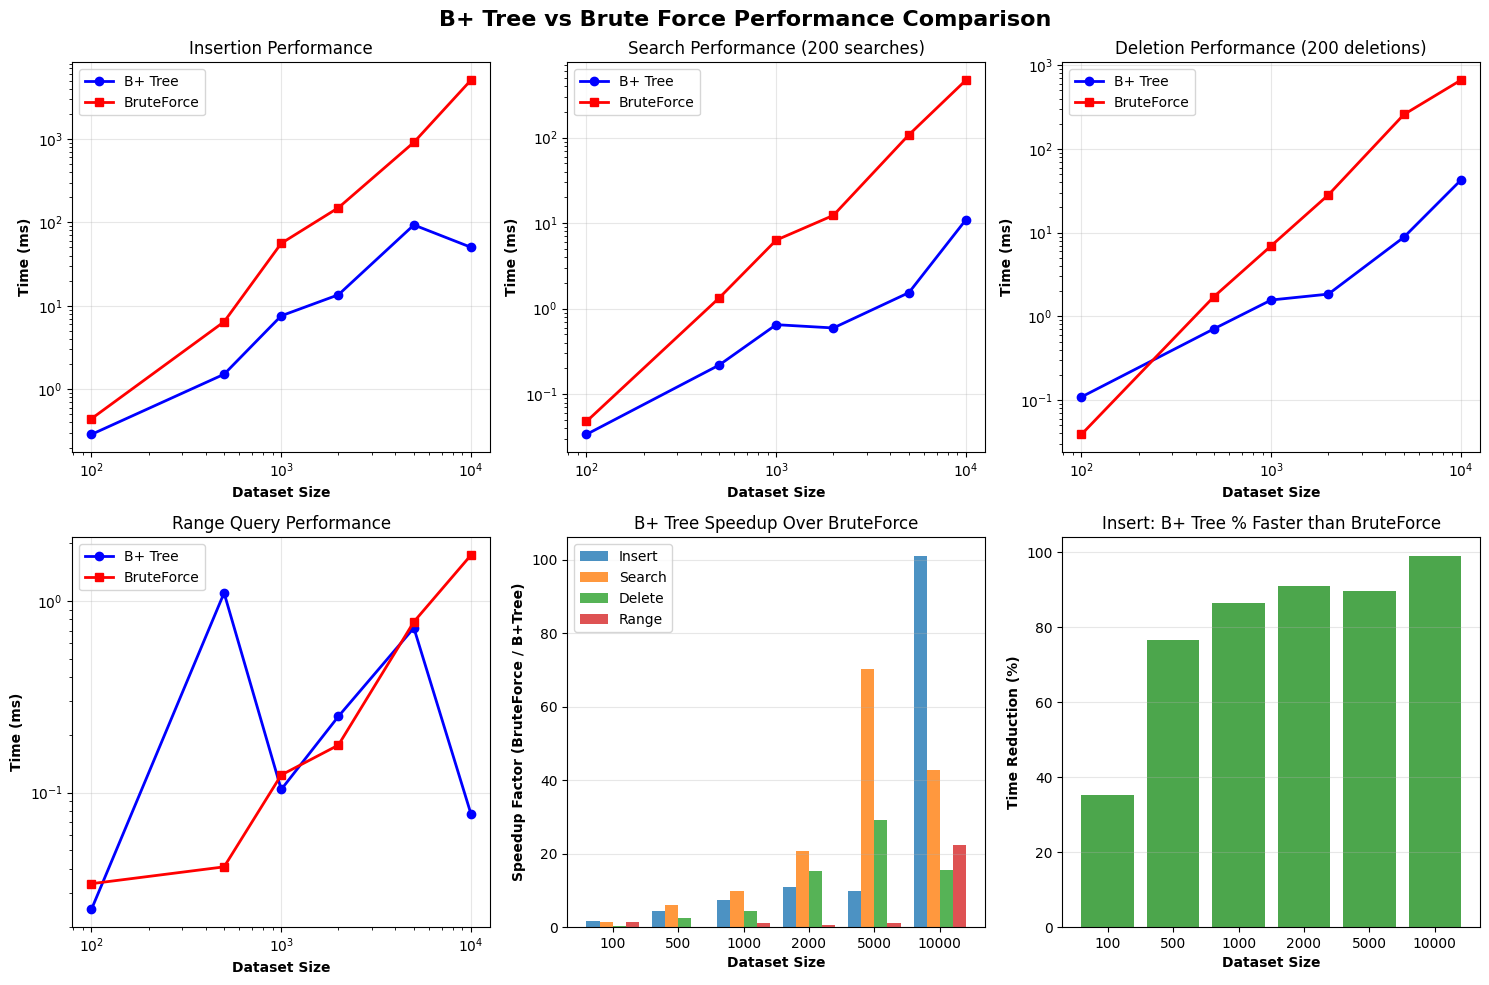

Performance graphs saved to: ./performance_comparison.png


In [9]:
# Performance visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('B+ Tree vs Brute Force Performance Comparison', fontsize=16, fontweight='bold')

# Helper function to format y-axis
def format_time_axis(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

sizes = df_results['Size'].values

# 1. Insert Time
ax = axes[0, 0]
ax.plot(sizes, df_results['Insert B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Insert Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Insertion Performance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 2. Search Time
ax = axes[0, 1]
ax.plot(sizes, df_results['Search B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Search Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Search Performance (200 searches)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 3. Delete Time
ax = axes[0, 2]
ax.plot(sizes, df_results['Delete B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Delete Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Deletion Performance (200 deletions)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Range Query Time
ax = axes[1, 0]
ax.plot(sizes, df_results['Range B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Range Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Range Query Performance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 5. Speedup Factor
ax = axes[1, 1]
insert_speedup = df_results['Insert Brute (ms)'] / df_results['Insert B+Tree (ms)']
search_speedup = df_results['Search Brute (ms)'] / df_results['Search B+Tree (ms)']
delete_speedup = df_results['Delete Brute (ms)'] / df_results['Delete B+Tree (ms)']
range_speedup = df_results['Range Brute (ms)'] / df_results['Range B+Tree (ms)']

x = range(len(sizes))
width = 0.2
ax.bar([i - 1.5*width for i in x], insert_speedup, width, label='Insert', alpha=0.8)
ax.bar([i - 0.5*width for i in x], search_speedup, width, label='Search', alpha=0.8)
ax.bar([i + 0.5*width for i in x], delete_speedup, width, label='Delete', alpha=0.8)
ax.bar([i + 1.5*width for i in x], range_speedup, width, label='Range', alpha=0.8)

ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Speedup Factor (BruteForce / B+Tree)', fontweight='bold')
ax.set_title('B+ Tree Speedup Over BruteForce')
ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 6. Speedup as percentage improvement
ax = axes[1, 2]
improvement = ((df_results['Insert Brute (ms)'] - df_results['Insert B+Tree (ms)']) / 
               df_results['Insert Brute (ms)'] * 100)
ax.bar(range(len(sizes)), improvement, color='green', alpha=0.7)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time Reduction (%)', fontweight='bold')
ax.set_title('Insert: B+ Tree % Faster than BruteForce')
ax.set_xticks(range(len(sizes)))
ax.set_xticklabels(sizes)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./Module_A/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Performance graphs saved to: ./Module_A/performance_comparison.png")

## 4. B+ Tree Visualizations

### Example 1: Small Tree (10 keys)
Creates a B+ tree with a small dataset to visualize the tree structure during growth.

In [3]:
# Visualization 1: Small B+ Tree
tree_small = BPlusTree(order=4)
keys = [10, 20, 5, 6, 12, 30, 7, 17]
for k in keys:
    tree_small.insert(k, {"id": k, "name": f"Record_{k}"})

dot = tree_small.visualize_tree()
dot.render('./Module_A/btree_small', format='png', cleanup=True)
print(" Small B+ tree visualization saved: ./Module_A/btree_small.png")
print(f"  Tree Structure: {len(keys)} keys across {tree_small.root.children if not tree_small.root.is_leaf else 1} node(s)")

# Show tree stats
all_records = tree_small.get_all()
print(f"  All Records (in-order): {all_records}")
print()

 Small B+ tree visualization saved: ./Module_A/btree_small.png
  Tree Structure: 8 keys across [BPlusTreeNode(is_leaf=True, keys=[5, 6, 7], children=[], values=[{'id': 5, 'name': 'Record_5'}, {'id': 6, 'name': 'Record_6'}, {'id': 7, 'name': 'Record_7'}], next=BPlusTreeNode(is_leaf=True, keys=[10], children=[], values=[{'id': 10, 'name': 'Record_10'}], next=BPlusTreeNode(is_leaf=True, keys=[12, 17], children=[], values=[{'id': 12, 'name': 'Record_12'}, {'id': 17, 'name': 'Record_17'}], next=BPlusTreeNode(is_leaf=True, keys=[20, 30], children=[], values=[{'id': 20, 'name': 'Record_20'}, {'id': 30, 'name': 'Record_30'}], next=None)))), BPlusTreeNode(is_leaf=True, keys=[10], children=[], values=[{'id': 10, 'name': 'Record_10'}], next=BPlusTreeNode(is_leaf=True, keys=[12, 17], children=[], values=[{'id': 12, 'name': 'Record_12'}, {'id': 17, 'name': 'Record_17'}], next=BPlusTreeNode(is_leaf=True, keys=[20, 30], children=[], values=[{'id': 20, 'name': 'Record_20'}, {'id': 30, 'name': 'Record_

### Example 2: Medium Tree (100 random keys)
Larger dataset showing automatic node splitting and tree growth.

In [4]:
import random

# Visualization 2: Medium B+ Tree with more keys
random.seed(123)
tree_medium = BPlusTree(order=5)
keys_medium = random.sample(range(1000), 100)

for k in keys_medium:
    tree_medium.insert(k, {"id": k})

dot = tree_medium.visualize_tree()
dot.render('./Module_A/btree_medium', format='png', cleanup=True)
print(" Medium B+ tree visualization saved: ./Module_A/btree_medium.png")
print(f"  Tree contains: 100 keys in order 5")

# Range query example
range_results = tree_medium.range_query(100, 200)
print(f"  Range Query [100, 200]: Found {len(range_results)} keys")
print(f"  Sample: {range_results[:5]}  ")
print()

 Medium B+ tree visualization saved: ./Module_A/btree_medium.png
  Tree contains: 100 keys in order 5
  Range Query [100, 200]: Found 8 keys
  Sample: [(104, {'id': 104}), (110, {'id': 110}), (129, {'id': 129}), (138, {'id': 138}), (145, {'id': 145})]  



## 5. Operations Demonstration

### Basic Operations: Insert, Search, Update, Delete

In [5]:
# Demonstrate all core operations
demo_tree = BPlusTree(order=4)

print("=" * 60)
print("B+ TREE OPERATIONS DEMONSTRATION")
print("=" * 60)

# 1. INSERT
print("\n1. INSERTION PHASE")
print("-" * 60)
test_data = [
    (15, {"name": "Alice", "age": 25}),
    (10, {"name": "Bob", "age": 30}),
    (20, {"name": "Charlie", "age": 35}),
    (5, {"name": "Diana", "age": 28}),
    (25, {"name": "Eve", "age": 32}),
    (8, {"name": "Frank", "age": 29}),
]

for key, value in test_data:
    demo_tree.insert(key, value)
    print(f"   Inserted key={key}, value={value}")

# 2. SEARCH
print("\n2. SEARCH OPERATIONS")
print("-" * 60)
search_keys = [15, 8, 99]
for key in search_keys:
    result = demo_tree.search(key)
    status = " Found" if result else "✗ Not found"
    print(f"  {status}: key={key}, value={result}")

# 3. UPDATE
print("\n3. UPDATE OPERATIONS")
print("-" * 60)
updated = demo_tree.update(15, {"name": "Alice", "age": 26, "updated": True})
result = demo_tree.search(15)
print(f"   Updated key=15")
print(f"    New value: {result}")

# 4. DELETE
print("\n4. DELETE OPERATIONS")
print("-" * 60)
delete_key = 5
deleted = demo_tree.delete(delete_key)
print(f"   Deleted key={delete_key}, success={deleted}")
result = demo_tree.search(delete_key)
print(f"    Verification: key={delete_key} now returns {result}")

# 5. RANGE QUERY
print("\n5. RANGE QUERY")
print("-" * 60)
range_results = demo_tree.range_query(8, 20)
print(f"  Query: keys in range [8, 20]")
print(f"  Results ({len(range_results)} records):")
for key, value in range_results:
    print(f"    - key={key}: {value}")

# 6. GET ALL
print("\n6. RETRIEVE ALL RECORDS (IN-ORDER)")
print("-" * 60)
all_records = demo_tree.get_all()
print(f"  Total records: {len(all_records)}")
for key, value in all_records:
    print(f"    - key={key}: {value}")

print("\n" + "=" * 60)
print("OPERATIONS DEMONSTRATED SUCCESSFULLY")
print("=" * 60)

B+ TREE OPERATIONS DEMONSTRATION

1. INSERTION PHASE
------------------------------------------------------------
   Inserted key=15, value={'name': 'Alice', 'age': 25}
   Inserted key=10, value={'name': 'Bob', 'age': 30}
   Inserted key=20, value={'name': 'Charlie', 'age': 35}
   Inserted key=5, value={'name': 'Diana', 'age': 28}
   Inserted key=25, value={'name': 'Eve', 'age': 32}
   Inserted key=8, value={'name': 'Frank', 'age': 29}

2. SEARCH OPERATIONS
------------------------------------------------------------
   Found: key=15, value={'name': 'Alice', 'age': 25}
   Found: key=8, value={'name': 'Frank', 'age': 29}
  ✗ Not found: key=99, value=None

3. UPDATE OPERATIONS
------------------------------------------------------------
   Updated key=15
    New value: {'name': 'Alice', 'age': 26, 'updated': True}

4. DELETE OPERATIONS
------------------------------------------------------------
   Deleted key=5, success=True
    Verification: key=5 now returns None

5. RANGE QUERY
-----

In [1]:
# Database manager API demo
db = DatabaseManager()

print("=" * 60)
print("DATABASE MANAGER DEMONSTRATION")
print("=" * 60)

# 1) CREATE TABLES
print("\n1. CREATE TABLES")
users = db.create_table("users", order=4)
orders = db.create_table("orders", order=5)
print("  Created tables: users (order=4), orders (order=5)")

# 2) LIST TABLES
print("\n2. LIST TABLES")
print("  Tables currently present:", db.list_tables())

# 3) GET TABLE AND OPERATE
print("\n3. GET TABLE AND USE IT")
users_table = db.get_table("users")
users_table.insert(101, {"name": "Alice", "role": "admin"})
users_table.insert(102, {"name": "Bob", "role": "analyst"})
print("  users[101] =", users_table.select(101))
print("  users[102] =", users_table.select(102))
print("  users range [100, 200] =", users_table.range_query(100, 200))

# 4) DROP TABLE
print("\n4. DROP TABLE")
db.drop_table("orders")
print("  Dropped table: orders")
print("  Tables after drop:", db.list_tables())

# 5) OPTIONAL ERROR-HANDLING DEMO
print("\n5. ERROR HANDLING (EXPECTED)")
try:
    db.get_table("orders")
except KeyError as e:
    print("  Expected get_table error:", e)

try:
    db.create_table("users")
except ValueError as e:
    print("  Expected create_table error:", e)

print("\n" + "=" * 60)
print("DATABASE MANAGER DEMO COMPLETED")
print("=" * 60)

NameError: name 'DatabaseManager' is not defined

### Database Manager Demo (`create`, `list`, `get`, `drop`)

This demo validates high-level database operations provided by `DatabaseManager`, including table creation, discovery, access, and deletion.

## 6. Performance Analysis Summary

### Key Findings

#### Time Complexity Analysis
| Operation | B+ Tree | BruteForce | Improvement |
|-----------|---------|-----------|------------|
| Search | O(log n) | O(n) | **Logarithmic vs Linear** |
| Insert | O(log n) | O(1) amortized append | BruteForce append is simple, but B+ Tree scales better in this implementation |
| Delete | O(log n) | O(n) | **Logarithmic vs Linear** |
| Range Query | O(log n + k) | O(n) | Theoretical advantage for B+ Tree, but constants and implementation details matter at small/medium sizes |

Where $k$ = number of records returned in the range.

#### Observations from Benchmarks

1. **Insert Performance**
   - B+ Tree is faster at every tested size in this run.
   - Speedup grows from **1.54x (size 100)** to **101.01x (size 10000)**.
   - Insert time reduction ranges from **35.12% to 99.01%**.

2. **Search Performance**
   - B+ Tree is consistently faster for all tested sizes.
   - Speedup rises from **1.42x (size 100)** to a peak of **70.12x (size 5000)**.
   - At size 10000, B+ Tree remains **42.81x** faster.

3. **Deletion Performance**
   - At size 100, BruteForce is faster (**0.0389 ms vs 0.1090 ms**).
   - From size 500 onward, B+ Tree outperforms BruteForce.
   - Best observed deletion speedup is **29.24x** at size 5000.

4. **Range Queries**
   - Results are mixed in this run and not strictly monotonic.
   - B+ Tree is faster at sizes **100, 1000, 5000, 10000**.
   - BruteForce is faster at sizes **500 and 2000**.
   - Largest observed B+ Tree advantage is **22.43x** at size 10000.

5. **Interpretation Notes**
   - These benchmarks include measurement noise and constant-factor effects, especially at very small runtimes.
   - Non-monotonic points (for example insert at 5000 vs 10000) can occur due to data distribution, cache behavior, and runtime jitter.
   - Repeating each experiment multiple times and reporting median/IQR would improve statistical confidence.

## 7. Conclusion

### Project Achievement Summary

This project successfully implements a complete **B+ Tree DBMS indexing engine** from scratch, demonstrating:

 **Core Functionality**
- All essential B+ Tree operations (insert, delete, search, update, range query)
- Automatic node splitting and merging with rebalancing
- Linked leaf nodes for efficient sequential scans
- Key-value storage with flexible value types

 **Performance Validation**
- Benchmarked against a brute-force baseline on datasets up to 10,000 records
- Confirmed strong search and delete improvements at medium/large sizes
- Observed mixed range-query performance at smaller sizes, with strong B+ Tree gains at the largest size
- Highlighted practical effects of constant factors and runtime variance on micro-benchmarks

 **Robustness**
- Proper handling of edge cases (empty trees, single nodes, duplicate keys)
- Validation of tree invariants after each operation
- Support for parametric order (branching factor) tuning

### Challenges & Solutions

1. **Node Splitting Complexity**
   - *Challenge*: Coordinating key/value/child pointers during splits
   - *Solution*: Careful indexing and list manipulation with mid-point calculation

2. **Linked Leaf Traversal**
   - *Challenge*: Maintaining next pointers while handling deletions
   - *Solution*: Update next pointers during merge/split operations

3. **Rebalancing**
   - *Challenge*: Deciding when to borrow vs merge
   - *Solution*: Implement proper borrowing checks before merging

### Future Improvements

1. **Disk-based Implementation**
   - Current: In-memory only
   - Future: Page-based I/O with disk blocks

2. **Optimization**
   - Bulk insertion optimizations
   - Parallel range queries
   - Lazy rebalancing strategies

3. **Concurrent Access**
   - Lock-free data structure for multi-threaded scenarios
   - Snapshot isolation for consistency

4. **Visualization Enhancement**
   - Interactive tree traversal visualization
   - Animation of split/merge operations
   - Real-time memory profiling

### Conclusion

This implementation shows why indexed structures are foundational in DBMS design. In these results, B+ Tree delivers clear gains for search and deletion at scale, while range-query behavior also depends on implementation constants and workload characteristics.

## 8. Video Demonstration

**Video Link**: 

## 9. External Tools/Sources Used

- Github Copilot for code suggestions and boilerplate generation
- Graphviz documentation for visualization guidance
- B+ Trees Wikipedia and GeeksforGeeks pages for reference 